In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
import keras 
import tensorflow as tf

In [2]:
#Loading the Dataset
#The dataset can be downloaded from here. It contains data from 2008 to 2017 and contains features like venue, date,
#batting and bowling team, names of batsman and bowler, wickets and more. We will load the IPL cricket data from CSV 
#files into pandas DataFrames to explore and prepare for modeling.
ipl = pd.read_csv(r"C:\Users\KIIT\Downloads\ipl_data.csv")
#ipl.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


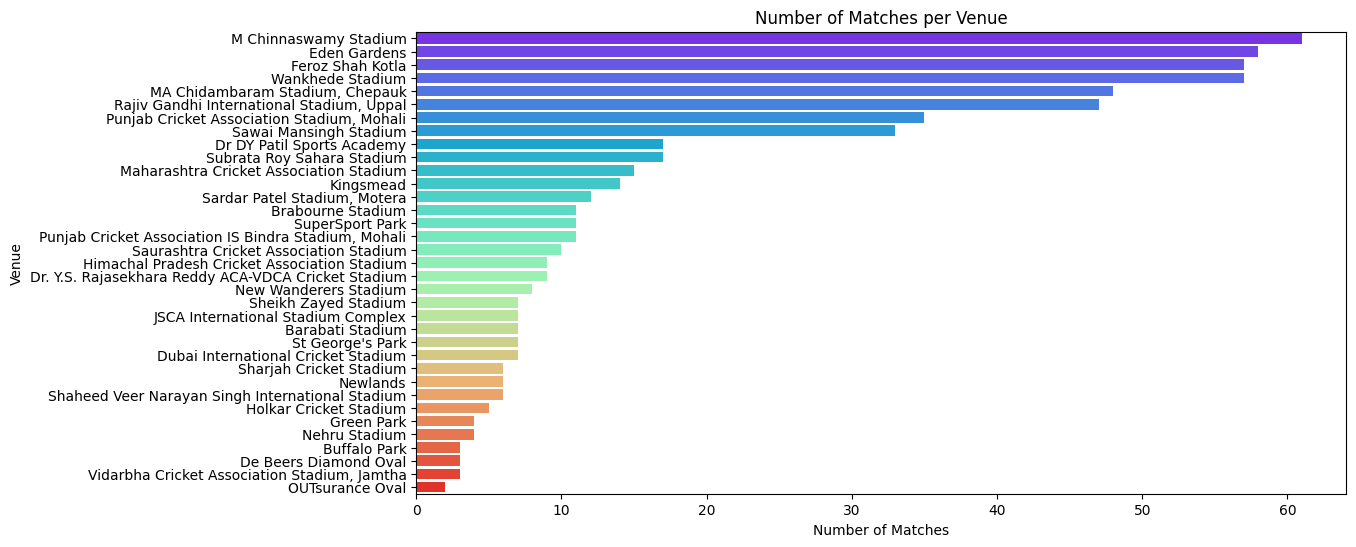

In [4]:
#Exploratory Data Analysis
#We will do Exploratory Data Analysis (EDA) to analyze how many unique matches have been played at each venue by 
#counting distinct match IDsfor every venue. Then, we’ll visualize this data using a horizontal bar chart to see which venues host the most matches.
import matplotlib.pyplot as plt
import seaborn as sns

data = ipl.copy()

matches_per_venue = data[['mid', 'venue']].drop_duplicates()
matches_count = matches_per_venue['venue'].value_counts()

plt.figure(figsize=(12,6))

sns.barplot(
    x=matches_count.values,
    y=matches_count.index,
    hue=matches_count.index,
    palette="rainbow",
    legend=False
)

plt.title('Number of Matches per Venue')
plt.xlabel('Number of Matches')
plt.ylabel('Venue')

plt.show()

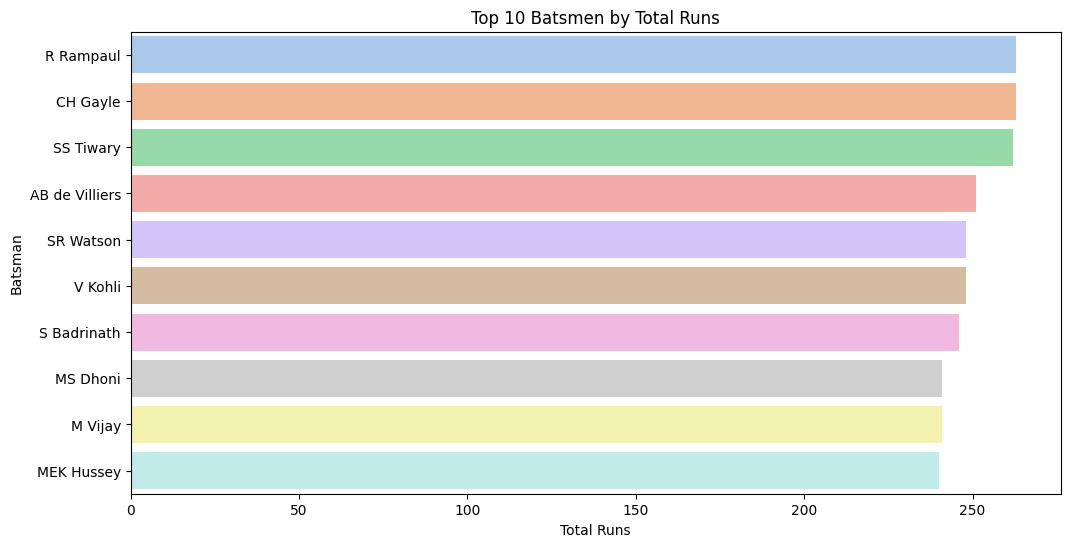

In [6]:
runs_df = runs_by_batsman.reset_index()
runs_df.columns = ['batsman', 'runs']

plt.figure(figsize=(12,6))

sns.barplot(
    data=runs_df,
    x='runs',
    y='batsman',
    hue='batsman',
    palette='pastel',
    legend=False
)

plt.title('Top 10 Batsmen by Total Runs')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')

plt.show()

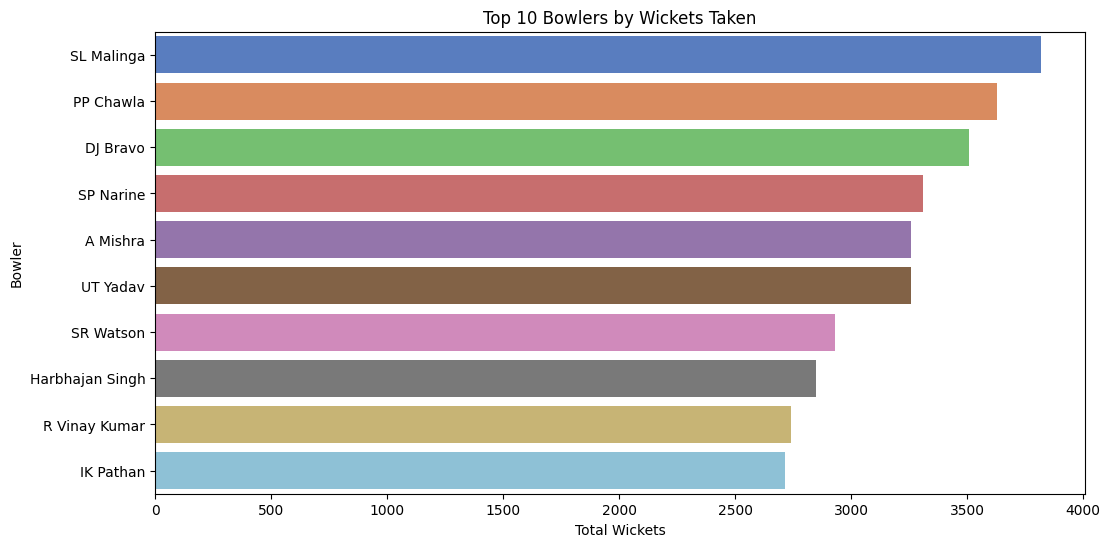

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
wickets_by_bowler = data.groupby('bowler')['wickets'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    x=wickets_by_bowler.values,
    y=wickets_by_bowler.index,
    hue=wickets_by_bowler.index,
    palette="muted",
    legend=False
)
plt.title('Top 10 Bowlers by Wickets Taken')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.show()

In [10]:
#Performing Label Encoding
#We will convert categorical text data into numeric labels using Label Encoding because ML models work with numbers.
#LabelEncoder() converts text labels into integers.
#fit_transform() learns encoding and applies it.
#copy() : creates a duplicate of the DataFrame to avoid changing the original data
#A dictionary assignment stores each encoder for future use like decoding or consistent transformation
from sklearn.preprocessing import LabelEncoder
cat_cols = ['bat_team', 'bowl_team', 'venue', "batsman", "bowler"]
data_encoded = data.copy()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    data_encoded[col] = le.fit_transform(data_encoded[col])
    label_encoders[col] = le

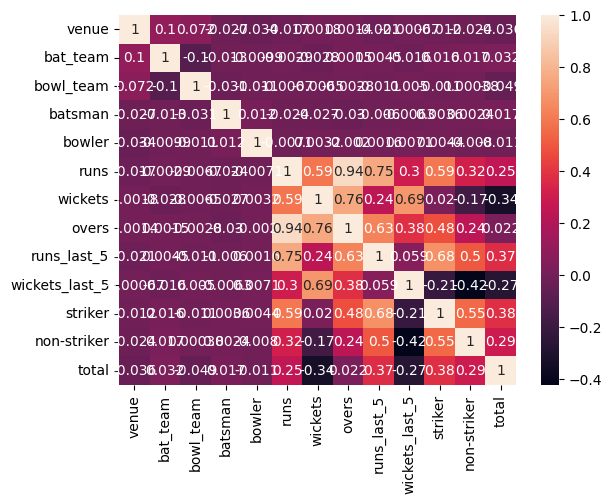

In [11]:
#Performing Feature Selection
#We drop date and mid columns because they are identifiers and don’t provide meaningful information for correlation analysis.
#By removing these irrelevant columns we focus on features that can reveal relationships useful for modeling or insights. Computing and visualizing correlations helps identify which features are related and can guide feature selection.
#drop() : removes specified columns from the DataFrame
#corr() : computes pairwise correlations between numerical features
#sns.heatmap() : creates a colored matrix to visualize correlations with values
#plt.show() : displays the plot on screen
#data_corr = data_encoded.drop(columns=["dat
data_corr = data_encoded.drop(columns=["date", "mid"], axis=1)
sns.heatmap(data_corr.corr(), annot=True)
plt.show()

In [12]:
#Splitting the Dataset into Training and Testing
#We will select relevant features and the target variable then split the data into training and testing sets for model building and evaluation.
#DataFrame indexing (data_encoded[feature_cols]) : selects specified columns as features
#train_test_split() : splits features and target into training and test subsets
#test_size=0.3 : assigns 30% of data for testing
#random_state=42 : ensures reproducible splits by fixing the random seed
from sklearn.model_selection import train_test_split
feature_cols = ['bat_team', 'bowl_team', 'venue', 'runs',
                'wickets', 'overs', 'striker', 'batsman', 'bowler']
X = data_encoded[feature_cols]
y = data_encoded['total']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
model = keras.Sequential([
    keras.layers.Input( shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(512, activation='relu'),  
    keras.layers.Dense(216, activation='relu'),  
    keras.layers.Dense(1, activation='linear') 
])

huber_loss = tf.keras.losses.Huber(delta=1.0)  # You can adjust the 'delta' parameter as needed
model.compile(optimizer='adam', loss=huber_loss)

In [15]:
#Training the Model
#We train the model on the scaled training data for 10 epochs with a batch size of 64, validating on the test set.
#model.fit() trains the model.
#epochs=10 means the model sees the whole data 10 times.
#batch_size=64 updates weights after every 64 samples.
#validation_data evaluates model on test set during training.
model.fit(X_train_scaled, y_train, epochs=10, batch_size=64, validation_data=(X_test_scaled, y_test))

Epoch 1/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 26.5002 - val_loss: 14.8200
Epoch 2/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 14.9182 - val_loss: 14.4585
Epoch 3/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 14.7046 - val_loss: 14.3209
Epoch 4/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 14.6903 - val_loss: 14.5298
Epoch 5/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 14.6099 - val_loss: 14.1650
Epoch 6/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 14.5548 - val_loss: 14.4209
Epoch 7/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 14.4666 - val_loss: 14.0185
Epoch 8/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 14.3789 - val_loss: 14.3080
Epoch 9/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 14.2852 - val_loss: 13.8934
Epoch 10/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 14.2551 - val_loss: 13.8175


<Axes: >

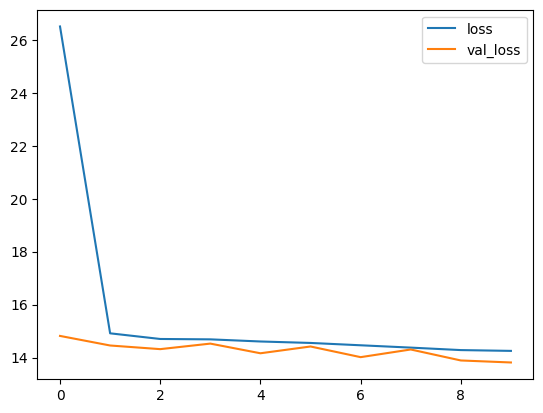

In [16]:
model_losses = pd.DataFrame(model.history.history)
model_losses.plot()

In [17]:
#Evaluating the Model
#We predict scores on test data and evaluate model performance using mean absolute error (MAE).
from sklearn.metrics import mean_absolute_error, mean_squared_error
predictions = model.predict(X_test_scaled)
mean_absolute_error(y_test, predictions)

713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


14.3079833984375

In [18]:
#Creating an Interactive Widget for Score Prediction
#We build an interactive interface using ipywidgets so users can select match details and get a live predicted score.
#widgets.Dropdown() creates dropdown menus.
#widgets.Button() creates a clickable button.
#predict_score() function handles user inputs, encodes and scales them, runs prediction and displays result.
#display() shows widgets in the notebook.
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings("ignore")
# Dropdown widgets
venue = widgets.Dropdown(
    options=list(label_encoders['venue'].classes_),
    description='Select Venue:'
)
batting_team = widgets.Dropdown(
    options=list(label_encoders['bat_team'].classes_),
    description='Select Batting Team:'
)
bowling_team = widgets.Dropdown(
    options=list(label_encoders['bowl_team'].classes_),
    description='Select Bowling Team:'
)
striker = widgets.Dropdown(
    options=list(label_encoders['batsman'].classes_),
    description='Select Striker:'
)
bowler = widgets.Dropdown(
    options=list(label_encoders['bowler'].classes_),
    description='Select Bowler:'
)
# Numeric inputs
runs = widgets.IntText(value=0, description='Runs:')
wickets = widgets.IntText(value=0, description='Wickets:')
overs = widgets.FloatText(value=0.0, description='Overs:')
striker_ind = widgets.IntText(value=0, description='Striker Index:')
# Button
predict_button = widgets.Button(description="Predict Score")
# Output box
output = widgets.Output()
# Prediction function
def predict_score(b):
    with output:
        clear_output()
        # Encode categorical inputs
        encoded_venue = label_encoders['venue'].transform([venue.value])[0]
        encoded_batting_team = label_encoders['bat_team'].transform([batting_team.value])[0]
        encoded_bowling_team = label_encoders['bowl_team'].transform([bowling_team.value])[0]
        encoded_striker = label_encoders['batsman'].transform([striker.value])[0]
        encoded_bowler = label_encoders['bowler'].transform([bowler.value])[0]
        # Create feature array
        input_features = [
            encoded_batting_team,
            encoded_bowling_team,
            encoded_venue,
            runs.value,
            wickets.value,
            overs.value,
            striker_ind.value,
            encoded_striker,
            encoded_bowler
        ]
        input_array = np.array(input_features).reshape(1, -1)
        # Scale input
        input_array = scaler.transform(input_array)
        # Predict
        predicted_score = model.predict(input_array)
        print("Predicted Total Runs:", int(predicted_score[0]))
# Button click event
predict_button.on_click(predict_score)
# Display widgets
display(
    venue,
    batting_team,
    bowling_team,
    striker,
    bowler,
    runs,
    wickets,
    overs,
    striker_ind,
    predict_button,
    output
)

Dropdown(description='Select Venue:', options=('Barabati Stadium', 'Brabourne Stadium', 'Buffalo Park', 'De Be…

Dropdown(description='Select Batting Team:', options=('Chennai Super Kings', 'Deccan Chargers', 'Delhi Daredev…

Dropdown(description='Select Bowling Team:', options=('Chennai Super Kings', 'Deccan Chargers', 'Delhi Daredev…

Dropdown(description='Select Striker:', options=('A Ashish Reddy', 'A Chandila', 'A Chopra', 'A Choudhary', 'A…

Dropdown(description='Select Bowler:', options=('A Ashish Reddy', 'A Chandila', 'A Choudhary', 'A Flintoff', '…

...

IntText(value=0, description='Wickets:')

FloatText(value=0.0, description='Overs:')

IntText(value=0, description='Striker Index:')

Button(description='Predict Score', style=ButtonStyle())

Output()